In [ ]:
# Análise de Determinantes Socioeconômicos

Nesta seção da Análise Exploratória de Dados (EDA), o foco é investigar como os fatores socioeconômicos do paciente — especificamente Renda e Escolaridade — se associam ao desfecho clínico (prevalência de Diabetes e Hipertensão) e ao acesso efetivo ao sistema de saúde.

A pergunta central que norteia este eixo é: **"Como renda e escolaridade se associam à prevalência de doenças crônicas e a barreiras financeiras de acesso a consultas médicas?"**

**Dataset:** CDC Diabetes Health Indicators (BRFSS 2015)

## 1. Setup e Carga de Dados
Iniciamos importando a base de dados principal e configurando o padrão visual (cores e estilo) utilizado em toda a identidade visual da análise.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Padrão visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
cor_primaria = '#0E766D'
cor_secundaria = '#D9534F'

# Carga do dataset
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Total de registros carregados: {len(df)}")

Total de registros carregados: 253680


In [ ]:
## 2. O Impacto da Renda e da Escolaridade
##Agrupamos as variáveis socioeconômicas `Income` (Renda) e `Education` (Escolaridade) para extrair a prevalência média de Diabetes, Hipertensão e da variável `NoDocbcCost` (indicador de que o paciente precisou ir ao médico nos últimos 12 meses, mas não pôde devido ao custo).

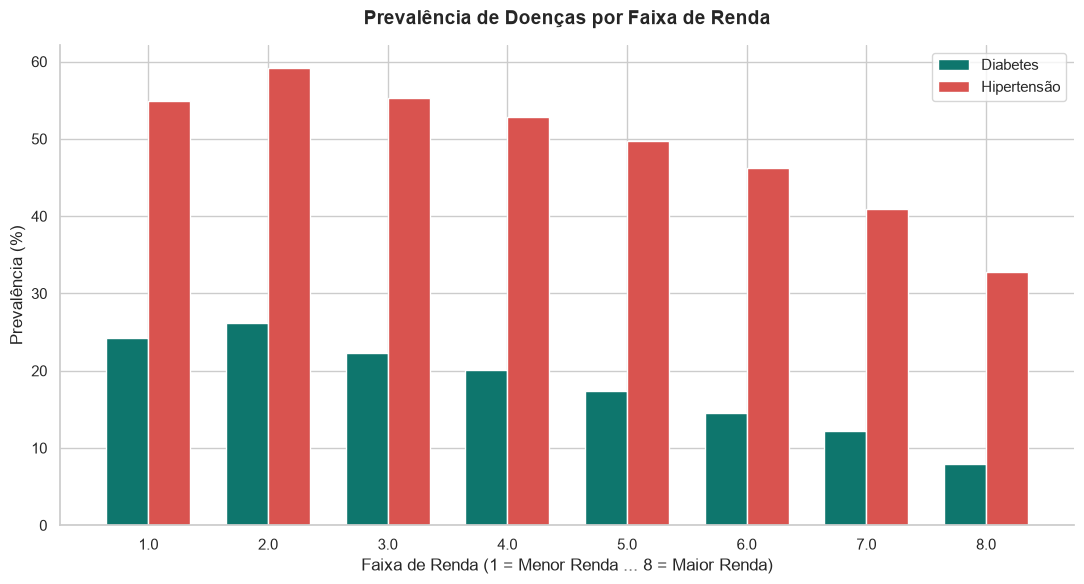

,Income,n,pct_diabetes,pct_hipertensao,pct_sem_medico
0,1.0,9811,24.29,54.88,21.37
1,2.0,11783,26.19,59.19,18.71
2,3.0,15994,22.31,55.30,17.43
3,4.0,20135,20.13,52.83,14.81
4,5.0,25883,17.40,49.75,11.29
5,6.0,36470,14.51,46.22,8.28
6,7.0,43219,12.18,40.90,6.06
7,8.0,90385,7.96,32.73,3.01


In [9]:
# Agregações para Renda (Income)
df_income = df.groupby('Income', observed=False).agg(
    n=('Diabetes_binary', 'size'),
    pct_diabetes=('Diabetes_binary', 'mean'),
    pct_hipertensao=('HighBP', 'mean'),
    pct_sem_medico=('NoDocbcCost', 'mean')
).reset_index()

for col in ['pct_diabetes', 'pct_hipertensao', 'pct_sem_medico']:
    df_income[col] = (df_income[col] * 100).round(2)

# Agregações para Escolaridade (Education)
df_edu = df.groupby('Education', observed=False).agg(
    n=('Diabetes_binary', 'size'),
    pct_diabetes=('Diabetes_binary', 'mean'),
    pct_hipertensao=('HighBP', 'mean'),
    pct_sem_medico=('NoDocbcCost', 'mean')
).reset_index()

for col in ['pct_diabetes', 'pct_hipertensao', 'pct_sem_medico']:
    df_edu[col] = (df_edu[col] * 100).round(2)

# Gráfico: Renda vs Diabetes e Hipertensão
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(df_income['Income']))
width = 0.35

ax.bar(x - width/2, df_income['pct_diabetes'], width, label='Diabetes', color=cor_primaria)
ax.bar(x + width/2, df_income['pct_hipertensao'], width, label='Hipertensão', color=cor_secundaria)

ax.set_ylabel('Prevalência (%)')
ax.set_xlabel('Faixa de Renda (1 = Menor Renda ... 8 = Maior Renda)')
ax.set_title('Prevalência de Doenças por Faixa de Renda', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_income['Income'])
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

display(df_income)

In [ ]:
#> **Interpretação:** Os dados revelam uma forte relação inversa. À medida que a faixa de renda diminui, a prevalência tanto de diabetes quanto de hipertensão aumenta substancialmente. Piorando o cenário socioclínico, essa mesma população de baixa renda e escolaridade é a que relata os maiores índices de barreira financeira (`NoDocbcCost`). Isso evidencia um **"duplo risco"**: maior carga da doença atrelada a um menor acesso ao diagnóstico formal e tratamento médico, justificando o uso de ferramentas de triagem digital para democratizar a informação.